<a href="https://colab.research.google.com/github/hlalsoukaina-dev/Murabaha-QP-Portfolio-Optimization./blob/main/Murabaha_QP_Framework_2019_2025_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Murabaha Portfolio QP Framework — Bank Al-Maghrib (2019–2025)
## Données Mourabaha Directes | Banques Participatives au Maroc

---
> **Thèse :** Quadratic Programming for Murabaha Portfolio Risk Management —
> A Strategic Asset Allocation Framework for Participatory Banks in Morocco (2019–2025)
>
> **Source :** `data.xlsx` — Statistiques mensuelles Bank Al-Maghrib (Mourabaha)
>
> **Unité :** Encours en MAD (Dirhams)
>
> **Secteurs :** Immobilier · Automobile · Équipement · Matières Premières
>
> **Période :** Juillet 2019 → Décembre 2025 (78 observations mensuelles)
>
> **Cadre théorique :** Markowitz (1952) — Mean-Variance Portfolio Optimization
>
> $$\min_{\mathbf{x}} \; \mathbf{x}^T \boldsymbol{\Sigma} \mathbf{x} \quad \text{s.t.} \quad \mathbf{x}^T\boldsymbol{\mu} \geq r^*, \; \sum x_i = 1, \; x_i \geq 0$$

---

## 🔹 Phase 1 — Imports & Configuration






In [ ]:
# ============================================================
# Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

plt.rcParams.update({
    'figure.dpi'        : 130,
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'figure.facecolor'  : 'white',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

PALETTE = {
    'RealEstate'  : '#1a6eb5',
    'Automotive'  : '#e07b39',
    'Equipment'   : '#2ba02b',
    'RawMaterials': '#d62728',
    'Total'       : '#7b2d8b'
}
SECTOR_COLS  = ['RealEstate', 'Automotive', 'Equipment', 'RawMaterials']
RETURN_COLS  = [f'Return_{c}' for c in SECTOR_COLS]
LABELS_FR    = ['Immobilier', 'Automobile', 'Équipement', 'Matières Premières']
COLORS       = [PALETTE[k] for k in SECTOR_COLS]

print(f"✅ Libraries loaded — pandas {pd.__version__} | numpy {np.__version__}")

✅ Libraries loaded — pandas 2.2.2 | numpy 2.0.2


---
## 🔹 Phase 2 — Chargement & Parsing des Données

> **Note académique :** Les données proviennent directement des statistiques mensuelles
> de Bank Al-Maghrib sur le financement Mourabaha, couvrant 4 secteurs sur 78 mois.
> La colonne `Date` (format YYYY-MM) est convertie en `DatetimeIndex` mensuel.


In [ ]:
# ============================================================
# Chargement du fichier source
# ============================================================
# Google Colab — décommentez pour uploader :
from google.colab import files
uploaded = files.upload()
FILE_PATH = list(uploaded.keys())[0]

FILE_PATH = 'data.xlsx'   # ← adaptez le chemin si nécessaire

steps = ['Lecture Excel', 'Conversion Date', 'Tri chronologique', 'Vérification']
with tqdm(steps, desc='📂 Chargement', ncols=72) as pbar:

    pbar.update()
    df_src = pd.read_excel(FILE_PATH)

    pbar.update()
    df_src['Date'] = pd.to_datetime(df_src['Date'], format='%Y-%m')
    df_src = df_src.set_index('Date')
    df_src.index = df_src.index.to_period('M')

    pbar.update()
    df_src = df_src.sort_index()

    pbar.update()
    assert df_src.index.is_monotonic_increasing

print(f"\n✅ Fichier chargé : {FILE_PATH}")
print(f"   Dimensions  : {df_src.shape[0]} lignes × {df_src.shape[1]} colonnes")
print(f"   Période     : {df_src.index[0]} → {df_src.index[-1]}")
print(f"   Unité       : MAD (Dirhams)")
print()
print("Colonnes brutes :")
for i, c in enumerate(df_src.columns, 1):
    print(f"  {i:2d}. {c}")

Saving data.xlsx to data (1).xlsx
Saving 4CPBFP.xlsx to 4CPBFP.xlsx


📂 Chargement: 100%|█████████████████████| 4/4 [00:00<00:00, 131.11it/s]


✅ Fichier chargé : data.xlsx
   Dimensions  : 78 lignes × 9 colonnes
   Période     : 2019-07 → 2025-12
   Unité       : MAD (Dirhams)

Colonnes brutes :
   1. Totale
   2. Immobilière
   3. Automobile
   4. Equipement
   5. Matieres Premieres
   6. Part Immobiliere %
   7. Part Automobile %
   8. Part Equipement %
   9. Part Matieres Premieres%


In [ ]:
# ============================================================
# Renommage & sélection des colonnes cibles
# ============================================================
RENAME_MAP = {
    'Totale'            : 'Total_MAD',
    'Immobilière'       : 'RealEstate_MAD',
    'Automobile'        : 'Automotive_MAD',
    'Equipement'        : 'Equipment_MAD',
    'Matieres Premieres': 'RawMaterials_MAD',
}
df_src = df_src.rename(columns=RENAME_MAP)

TARGET_COLS = ['Total_MAD', 'RealEstate_MAD', 'Automotive_MAD',
               'Equipment_MAD', 'RawMaterials_MAD']
df = df_src[TARGET_COLS].copy()

print("✅ Colonnes renommées et sélectionnées")
print(df.head(5).to_string())

✅ Colonnes renommées et sélectionnées
                Total_MAD    RealEstate_MAD   Automotive_MAD  Equipment_MAD  RawMaterials_MAD
Date                                                                                         
2019-07  7,174,906.000000  6,582,583.000000   568,053.000000  24,270.000000                 0
2019-08  7,440,867.000000  6,777,948.000000   635,442.000000  27,476.000000                 0
2019-09  7,838,303.000000  7,119,638.000000   689,016.000000  29,649.000000                 0
2019-10  8,262,660.000000  7,497,785.000000   733,150.000000  31,725.000000                 0
2019-11 12,837,464.000000 11,467,993.000000 1,098,045.000000 271,426.000000                 0


---
## 🔹 Phase 3 — Quality Check & Nettoyage

> **Note académique :** Trois types d'anomalies sont traités séquentiellement :
>
> 1. **Valeur manquante (Mai 2020)** → Interpolation linéaire
> 2. **Zéros structurels (Matières Premières avant Sept 2024)** → Remplacement par `NaN`
>    pour éviter les rendements infinis dans `pct_change()`
> 3. **Sauts extrêmes (Nov–Déc 2019)** → Winsorisation au percentile 1%–99%
>    appliquée sur les *rendements* uniquement, après calcul de `pct_change()`


In [ ]:
# ============================================================
# 3.1  Rapport de qualité initial
# ============================================================
print("=" * 70)
print("🔍 Rapport de Qualité Initial")
print("=" * 70)

missing = df.isnull().sum()
zeros   = (df == 0).sum()
qc = pd.DataFrame({
    'NaN'          : missing.values,
    'Zéros'        : zeros.values,
    'Obs totales'  : len(df),
    'Couverture %' : ((len(df) - missing.values) / len(df) * 100).round(1),
    'Statut'       : ['⚠️' if (m + z) > 0 else '✅'
                      for m, z in zip(missing.values, zeros.values)]
}, index=TARGET_COLS)
print(qc.to_string())

# Doublon d'index ?
dup_idx = df.index.duplicated().sum()
print(f"\n   Doublons d'index : {'Aucun ✅' if dup_idx == 0 else str(dup_idx) + ' ⚠️'}")

🔍 Rapport de Qualité Initial
                  NaN  Zéros  Obs totales  Couverture % Statut
Total_MAD           1      0           78     98.700000     ⚠️
RealEstate_MAD      1      0           78     98.700000     ⚠️
Automotive_MAD      1      0           78     98.700000     ⚠️
Equipment_MAD       1      0           78     98.700000     ⚠️
RawMaterials_MAD    0     62           78    100.000000     ⚠️

   Doublons d'index : Aucun ✅


In [ ]:
# ============================================================
# 3.2  Pipeline de nettoyage complet
# ============================================================
CLEAN_STEPS = [
    'Copie sécurisée',
    'Interp. linéaire — valeurs manquantes (Mai 2020)',
    'Zéros structurels RawMaterials → NaN',
    'Suppression doublons',
    'Validation finale'
]

with tqdm(CLEAN_STEPS, desc='🧹 Nettoyage', ncols=72) as pbar:

    pbar.update()
    df_clean = df.copy()

    # ── Étape 2 : interpolation pour les NaN (Mai 2020)
    pbar.update()
    before_nan = df_clean.isnull().sum().sum()
    interp_cols = ['Total_MAD', 'RealEstate_MAD', 'Automotive_MAD', 'Equipment_MAD']
    df_clean[interp_cols] = df_clean[interp_cols].interpolate(method='linear')
    after_nan = df_clean.isnull().sum().sum()

    # ── Étape 3 : zéros structurels RawMaterials → NaN
    pbar.update()
    n_zeros_raw = (df_clean['RawMaterials_MAD'] == 0).sum()
    df_clean['RawMaterials_MAD'] = df_clean['RawMaterials_MAD'].replace(0, np.nan)

    # ── Étape 4 : doublons
    pbar.update()
    df_clean = df_clean[~df_clean.index.duplicated(keep='first')]

    # ── Étape 5 : vérification
    pbar.update()
    assert df_clean.index.is_monotonic_increasing

print(f"\n✅ Nettoyage terminé")
print(f"   NaN corrigés par interpolation        : {before_nan - after_nan}")
print(f"   Zéros structurels RawMat → NaN        : {n_zeros_raw}")
print(f"   NaN restants (structurels RawMat)      : {df_clean['RawMaterials_MAD'].isnull().sum()}")
print(f"   Observations finales                   : {len(df_clean)}")

🧹 Nettoyage: 100%|██████████████████████| 5/5 [00:00<00:00, 742.70it/s]


✅ Nettoyage terminé
   NaN corrigés par interpolation        : 4
   Zéros structurels RawMat → NaN        : 62
   NaN restants (structurels RawMat)      : 62
   Observations finales                   : 78


---
## 🔹 Phase 4 — Feature Engineering : Parts Sectorielles & Rendements Mensuels

> **Note académique :** Les rendements mensuels $r_t = (V_t - V_{t-1})/V_{t-1}$ sont
> calculés via `pct_change()`. Les sauts extrêmes enregistrés en Nov–Déc 2019
> (restructuration comptable dans les données BAM) sont traités par **winsorisation**
> aux percentiles 1%–99% pour préserver la stationnarité de la série.


In [ ]:
# ============================================================
# 4.1  Parts sectorielles
# ============================================================
FIN_COLS = ['RealEstate_MAD', 'Automotive_MAD', 'Equipment_MAD', 'RawMaterials_MAD']
SHARE_COLS = ['Share_RealEstate_pct', 'Share_Automotive_pct',
              'Share_Equipment_pct', 'Share_RawMaterials_pct']

for fin_col, share_col in zip(FIN_COLS, SHARE_COLS):
    df_clean[share_col] = (df_clean[fin_col] / df_clean['Total_MAD'] * 100).round(4)

# Vérification : somme ≈ 100%
share_sum = df_clean[SHARE_COLS].sum(axis=1)
print(f"✅ Parts sectorielles calculées")
print(f"   Somme min : {share_sum.min():.4f}%  |  Somme max : {share_sum.max():.4f}%")
print()
print("Aperçu (5 premières lignes) :")
print(df_clean[SHARE_COLS].head(5).to_string())

✅ Parts sectorielles calculées
   Somme min : 98.4138%  |  Somme max : 110.6912%

Aperçu (5 premières lignes) :
         Share_RealEstate_pct  Share_Automotive_pct  Share_Equipment_pct  Share_RawMaterials_pct
Date                                                                                            
2019-07             91.744500              7.917200             0.338300                     NaN
2019-08             91.090800              8.539900             0.369300                     NaN
2019-09             90.831400              8.790400             0.378300                     NaN
2019-10             90.743000              8.873100             0.384000                     NaN
2019-11             89.332200              8.553400             2.114300                     NaN


In [ ]:
# ============================================================
# 4.2  Rendements mensuels bruts via pct_change()
# ============================================================
fin_series = df_clean[FIN_COLS].copy()
rets_raw   = fin_series.pct_change()
rets_raw.columns = RETURN_COLS

print("📊 Statistiques des rendements bruts :")
print((rets_raw * 100).describe().round(4).to_string())

# ── Détection des valeurs extrêmes ──────────────────────────
print("\n🔍 Valeurs extrêmes detectées (|r_t| > 50%) :")
extremes = []
for col in RETURN_COLS:
    mask = rets_raw[col].abs() > 0.5
    if mask.any():
        for period, val in rets_raw.loc[mask, col].items():
            extremes.append({'Période': str(period), 'Secteur': col,
                             'Rendement brut': f'{val*100:.2f}%',
                             'Cause probable': 'Restructuration comptable BAM'})
if extremes:
    print(pd.DataFrame(extremes).to_string(index=False))
else:
    print("  Aucune")

📊 Statistiques des rendements bruts :
       Return_RealEstate  Return_Automotive  Return_Equipment  Return_RawMaterials
count          77.000000          77.000000         77.000000            15.000000
mean            2.366800           2.210800         14.979300            -0.258200
std             7.182800           6.761000         86.385900             1.718200
min           -28.626400         -25.916600        -62.295800            -5.512500
25%             1.216000           0.713800          2.928100            -0.523900
50%             1.594900           1.677800          6.492000             0.069800
75%             2.550700           2.855600         10.501000             0.390100
max            52.951700          49.770900        755.558700             1.951900

🔍 Valeurs extrêmes detectées (|r_t| > 50%) :
Période           Secteur Rendement brut                Cause probable
2019-11 Return_RealEstate         52.95% Restructuration comptable BAM
2019-11  Return_Equipment  

In [ ]:
# ============================================================
# 4.3  Winsorisation des rendements (percentiles 1%–99%)
# ============================================================
# Justification : les sauts Nov–Déc 2019 (+52% / -28% Immobilier ;
# +755% / -62% Équipement) résultent d'une révision comptable ponctuelle
# de BAM et non d'un choc économique réel. La winsorisation préserve
# la structure des données tout en éliminant les distorsions extrêmes.

WIN_STEPS = ['Calcul percentiles', 'Clipping rendements', 'Fusion dans df_clean']

with tqdm(WIN_STEPS, desc='✂️  Winsorisation', ncols=72) as pbar:

    pbar.update()
    rets_win = rets_raw.copy()
    p_low  = rets_raw.quantile(0.01)
    p_high = rets_raw.quantile(0.99)

    pbar.update()
    for col in RETURN_COLS:
        rets_win[col] = rets_raw[col].clip(lower=p_low[col], upper=p_high[col])

    pbar.update()
    df_clean = pd.concat([df_clean, rets_win], axis=1)

# Rapport avant / après
print("\n📋 Impact de la winsorisation :")
compare_w = pd.DataFrame({
    'Secteur'      : LABELS_FR,
    'σ brut %/mois': [rets_raw[c].std()*100 for c in RETURN_COLS],
    'σ wins %/mois': [rets_win[c].std()*100 for c in RETURN_COLS],
    'Max brut %'   : [rets_raw[c].max()*100 for c in RETURN_COLS],
    'Max wins %'   : [rets_win[c].max()*100 for c in RETURN_COLS],
    'Min brut %'   : [rets_raw[c].min()*100 for c in RETURN_COLS],
    'Min wins %'   : [rets_win[c].min()*100 for c in RETURN_COLS],
})
print(compare_w.round(4).to_string(index=False))

✂️  Winsorisation: 100%|█████████████████| 3/3 [00:00<00:00, 337.92it/s]


📋 Impact de la winsorisation :
           Secteur  σ brut %/mois  σ wins %/mois  Max brut %  Max wins %  Min brut %  Min wins %
        Immobilier       7.182800       3.866200   52.951700   25.395200  -28.626400  -11.971300
        Automobile       6.761000       3.442100   49.770900   20.961000  -25.916600   -9.182100
        Équipement      86.385900      25.840300  755.558700  206.697400  -62.295800  -56.411300
Matières Premières       1.718200       1.602200    1.951900    1.906900   -5.512500   -4.994000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 🔹 Phase 5 — Matrices de Risque : μ, Σ, Corrélation

> **Note académique :** Ces matrices constituent les **inputs directs** du solveur QP.
>
> | Matrice | Symbole | Rôle dans QP |
> |---------|---------|-------------|
> | Rendements espérés | **μ** | Contrainte : $\mathbf{x}^T\boldsymbol{\mu} \geq r^*$ |
> | Var-Covariance | **Σ** | Objectif : $\min \mathbf{x}^T\boldsymbol{\Sigma}\mathbf{x}$ |
> | Corrélation | **R** | Évaluation de la diversification |
>
> Les rendements winsorisés sont utilisés pour **μ** et **Σ** afin d'éviter
> que les chocs ponctuels ne biaisent les estimateurs.


In [ ]:
# ============================================================
# 5.1  Vecteur des rendements espérés  μ
# ============================================================
MIN_OBS = 12
ret_series = df_clean[RETURN_COLS].dropna(how='all')

valid_cols  = [c for c in RETURN_COLS if ret_series[c].notna().sum() >= MIN_OBS]
excluded    = [c for c in RETURN_COLS if c not in valid_cols]

if excluded:
    print(f"⚠️  Exclus (obs < {MIN_OBS}) : {excluded}")

mu_vec = ret_series[valid_cols].mean()

label_map = dict(zip(RETURN_COLS, LABELS_FR))

mu_df = pd.DataFrame({
    'Secteur'              : [label_map[c] for c in valid_cols],
    'μ mensuel'            : mu_vec.values,
    'μ annualisé'          : mu_vec.values * 12,
    'σ mensuel'            : [ret_series[c].std() for c in valid_cols],
    'σ annualisé'          : [ret_series[c].std() * np.sqrt(12) for c in valid_cols],
    'Ratio μ/σ (Sharpe~)'  : [mu_vec[c] / ret_series[c].std()
                               if ret_series[c].std() > 0 else np.nan
                               for c in valid_cols],
    'Obs valides'          : [ret_series[c].notna().sum() for c in valid_cols],
})

print("=" * 75)
print("📐 Vecteur des Rendements Espérés  μ  (rendements winsorisés)")
print("=" * 75)
print(mu_df.round(6).to_string(index=False))
print(f"\n   μ array → {np.round(mu_vec.values, 6)}")

📐 Vecteur des Rendements Espérés  μ  (rendements winsorisés)
           Secteur  μ mensuel  μ annualisé  σ mensuel  σ annualisé  Ratio μ/σ (Sharpe~)  Obs valides
        Immobilier   0.022252     0.267024   0.038662     0.133929             0.575554           77
        Automobile   0.020540     0.246482   0.034421     0.119236             0.596741           77
        Équipement   0.079277     0.951322   0.258403     0.895133             0.306796           77
Matières Premières  -0.002267    -0.027200   0.016022     0.055503            -0.141467           15

   μ array → [ 0.022252  0.02054   0.079277 -0.002267]


In [ ]:
# ============================================================
# 5.2  Matrice Variance-Covariance  Σ
# ============================================================
Sigma     = ret_series[valid_cols].cov()
Sigma_disp = Sigma.rename(index=label_map, columns=label_map)

print("=" * 75)
print("📐 Matrice Variance-Covariance  Σ  (rendements mensuels winsorisés)")
print("=" * 75)
print(Sigma_disp.round(8).to_string())

print("\n── Diagonale (Variances individuelles) ─────────────────────────────")
for c in valid_cols:
    var = Sigma.loc[c, c]
    std = np.sqrt(var)
    print(f"  {label_map[c]:22s}  σ² = {var:.8f}  |  σ = {std:.6f}  ({std*100:.4f}%/mois)")

# Vérification définie positive
eigenvalues = np.linalg.eigvals(Sigma.values)
is_pd = bool(np.all(eigenvalues > 0))
print(f"\n✅ Σ définie positive : {is_pd}  |  Valeurs propres : {np.round(eigenvalues, 8)}")

📐 Matrice Variance-Covariance  Σ  (rendements mensuels winsorisés)
                    Immobilier  Automobile  Équipement  Matières Premières
Immobilier            0.001495    0.000922    0.007220           -0.000017
Automobile            0.000922    0.001185    0.005993           -0.000015
Équipement            0.007220    0.005993    0.066772           -0.000083
Matières Premières   -0.000017   -0.000015   -0.000083            0.000257

── Diagonale (Variances individuelles) ─────────────────────────────
  Immobilier              σ² = 0.00149475  |  σ = 0.038662  (3.8662%/mois)
  Automobile              σ² = 0.00118477  |  σ = 0.034421  (3.4421%/mois)
  Équipement              σ² = 0.06677198  |  σ = 0.258403  (25.8403%/mois)
  Matières Premières      σ² = 0.00025672  |  σ = 0.016022  (1.6022%/mois)

✅ Σ définie positive : True  |  Valeurs propres : [0.06810942 0.00093787 0.00040449 0.00025643]


In [ ]:
# ============================================================
# 5.3  Matrice de Corrélation  R
# ============================================================
Corr      = ret_series[valid_cols].corr()
Corr_disp  = Corr.rename(index=label_map, columns=label_map)

print("=" * 65)
print("📐 Matrice de Corrélation  R")
print("=" * 65)
print(Corr_disp.round(4).to_string())

print("\n── Interprétation des paires ────────────────────────────────────────")
for i, ci in enumerate(valid_cols):
    for j, cj in enumerate(valid_cols):
        if j > i:
            r   = Corr.loc[ci, cj]
            lvl = 'Forte' if abs(r) > .7 else ('Modérée' if abs(r) > .4 else 'Faible')
            dir = 'positive' if r > 0 else 'négative'
            print(f"  {label_map[ci]:22s} × {label_map[cj]:22s} "
                  f"r = {r:+.4f}  ({lvl}, {dir})")

📐 Matrice de Corrélation  R
                    Immobilier  Automobile  Équipement  Matières Premières
Immobilier            1.000000    0.692800    0.722700           -0.319800
Automobile            0.692800    1.000000    0.673800           -0.120500
Équipement            0.722700    0.673800    1.000000           -0.084600
Matières Premières   -0.319800   -0.120500   -0.084600            1.000000

── Interprétation des paires ────────────────────────────────────────
  Immobilier             × Automobile             r = +0.6928  (Modérée, positive)
  Immobilier             × Équipement             r = +0.7227  (Forte, positive)
  Immobilier             × Matières Premières     r = -0.3198  (Faible, négative)
  Automobile             × Équipement             r = +0.6738  (Modérée, positive)
  Automobile             × Matières Premières     r = -0.1205  (Faible, négative)
  Équipement             × Matières Premières     r = -0.0846  (Faible, négative)


In [ ]:
# ============================================================
# 5.4  Récapitulatif QP — inputs pour le solveur
# ============================================================
n = len(valid_cols)
print("=" * 70)
print("🎯 INPUTS QP — scipy.optimize.minimize / cvxpy")
print("=" * 70)
print(f"\n  n (secteurs / variables de décision) = {n}")
print(f"\n  μ — vecteur rendements espérés ({n}×1) :")
print(f"  {np.round(mu_vec.values, 6)}")
print(f"\n  Σ — matrice variance-covariance ({n}×{n}) :")
for row in Sigma.values:
    print(f"  {np.round(row, 8)}")
print(f"\n  Contraintes standard :")
print(f"    [Budget]    Σxᵢ = 1          (allocation = 100%)")
print(f"    [Rendement] xᵀμ ≥ r*         (rendement cible minimum)")
print(f"    [Non-négatif] xᵢ ≥ 0 ∀i     (pas de vente à découvert)")

🎯 INPUTS QP — scipy.optimize.minimize / cvxpy

  n (secteurs / variables de décision) = 4

  μ — vecteur rendements espérés (4×1) :
  [ 0.022252  0.02054   0.079277 -0.002267]

  Σ — matrice variance-covariance (4×4) :
  [ 1.49475e-03  9.21930e-04  7.22026e-03 -1.66900e-05]
  [ 9.21930e-04  1.18477e-03  5.99258e-03 -1.54400e-05]
  [ 7.220260e-03  5.992580e-03  6.677198e-02 -8.307000e-05]
  [-1.6690e-05 -1.5440e-05 -8.3070e-05  2.5672e-04]

  Contraintes standard :
    [Budget]    Σxᵢ = 1          (allocation = 100%)
    [Rendement] xᵀμ ≥ r*         (rendement cible minimum)
    [Non-négatif] xᵢ ≥ 0 ∀i     (pas de vente à découvert)


---
## 🔹 Phase 6 — Visualisations Professionnelles


In [ ]:
# ── Helpers ─────────────────────────────────────────────────────────────────
def to_ts(idx):
    """PeriodIndex → timestamps pour matplotlib."""
    return idx.to_timestamp()

x = to_ts(df_clean.index)

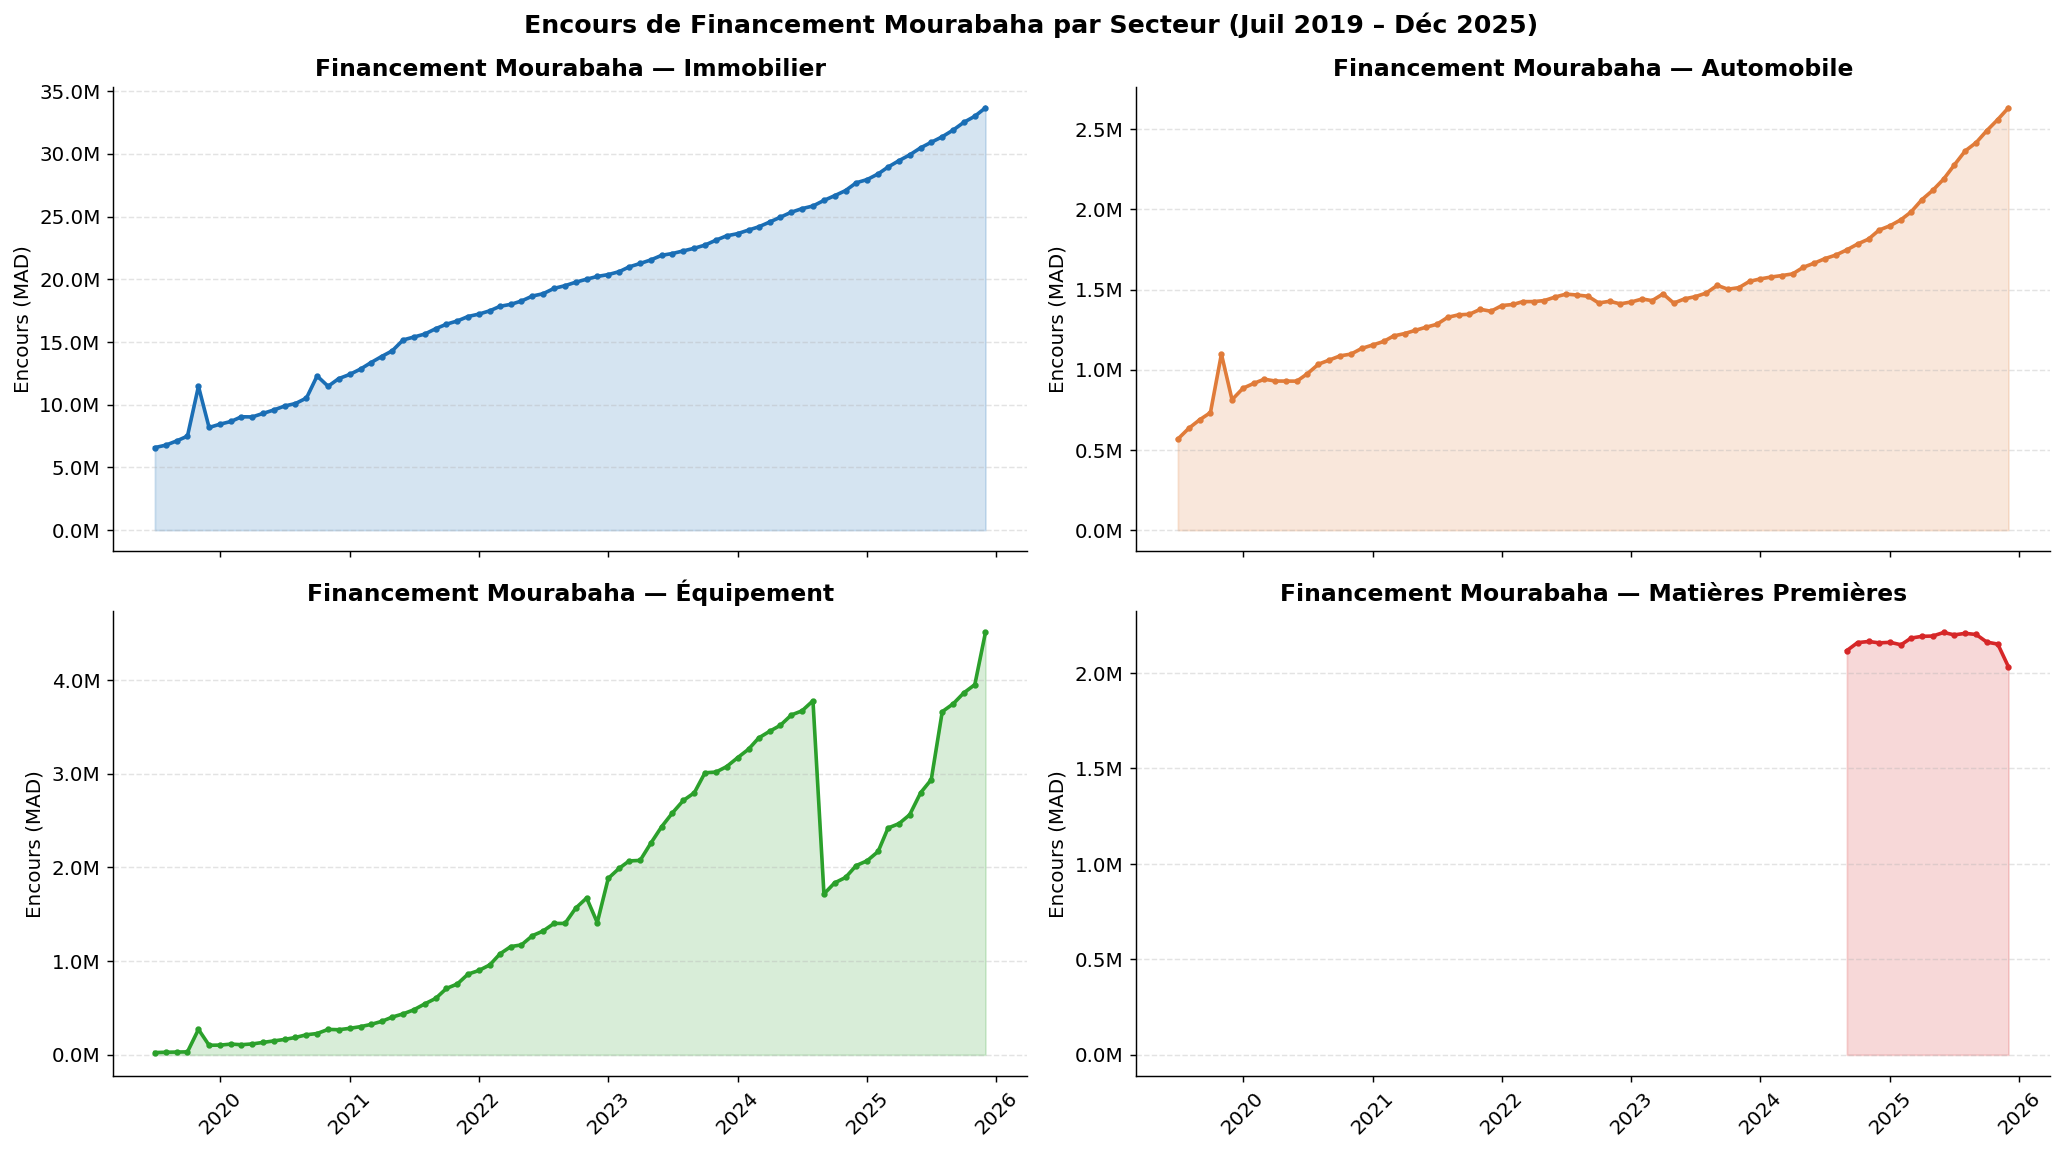

In [ ]:
# ============================================================
# 6.1  Encours bruts — tendances sectorielles (4 subplots)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for i, (col, lbl, color) in enumerate(zip(FIN_COLS, LABELS_FR, COLORS)):
    s = df_clean[col]
    axes[i].fill_between(x, s, alpha=0.18, color=color)
    axes[i].plot(x, s, color=color, lw=2, marker='o', ms=2.5)
    axes[i].set_title(f'Financement Mourabaha — {lbl}')
    axes[i].yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
    axes[i].set_ylabel('Encours (MAD)')
    axes[i].grid(axis='y', ls='--', alpha=0.35)
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle("Encours de Financement Mourabaha par Secteur (Juil 2019 – Déc 2025)",
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

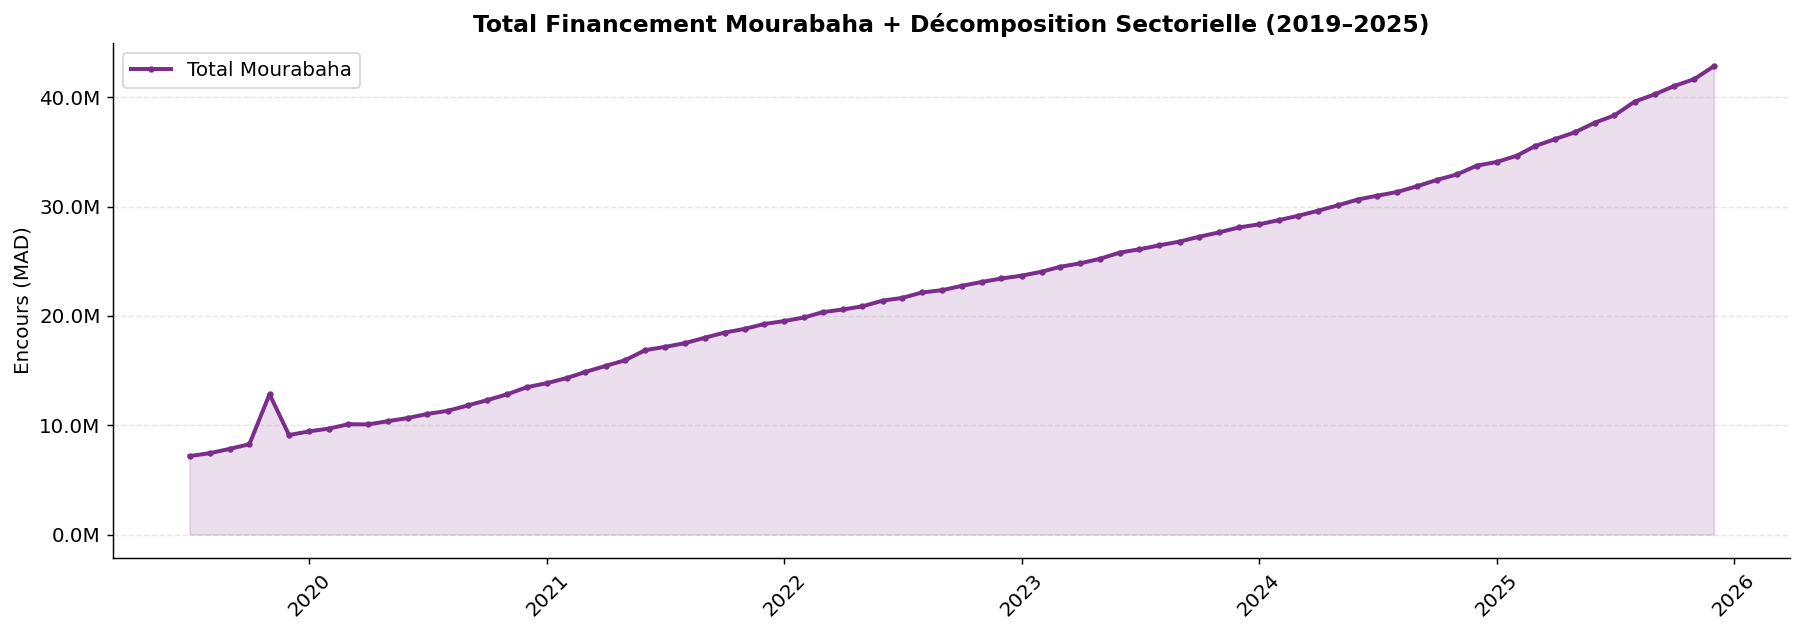

In [ ]:
# ============================================================
# 6.2  Total + décomposition sectorielle
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(x, df_clean['Total_MAD'], alpha=0.15, color=PALETTE['Total'])
ax.plot(x, df_clean['Total_MAD'], color=PALETTE['Total'],
        lw=2.2, marker='o', ms=2.5, label='Total Mourabaha')
ax.set_title('Total Financement Mourabaha + Décomposition Sectorielle (2019–2025)')
ax.set_ylabel('Encours (MAD)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', ls='--', alpha=0.3)
ax.legend()
plt.tight_layout(); plt.show()

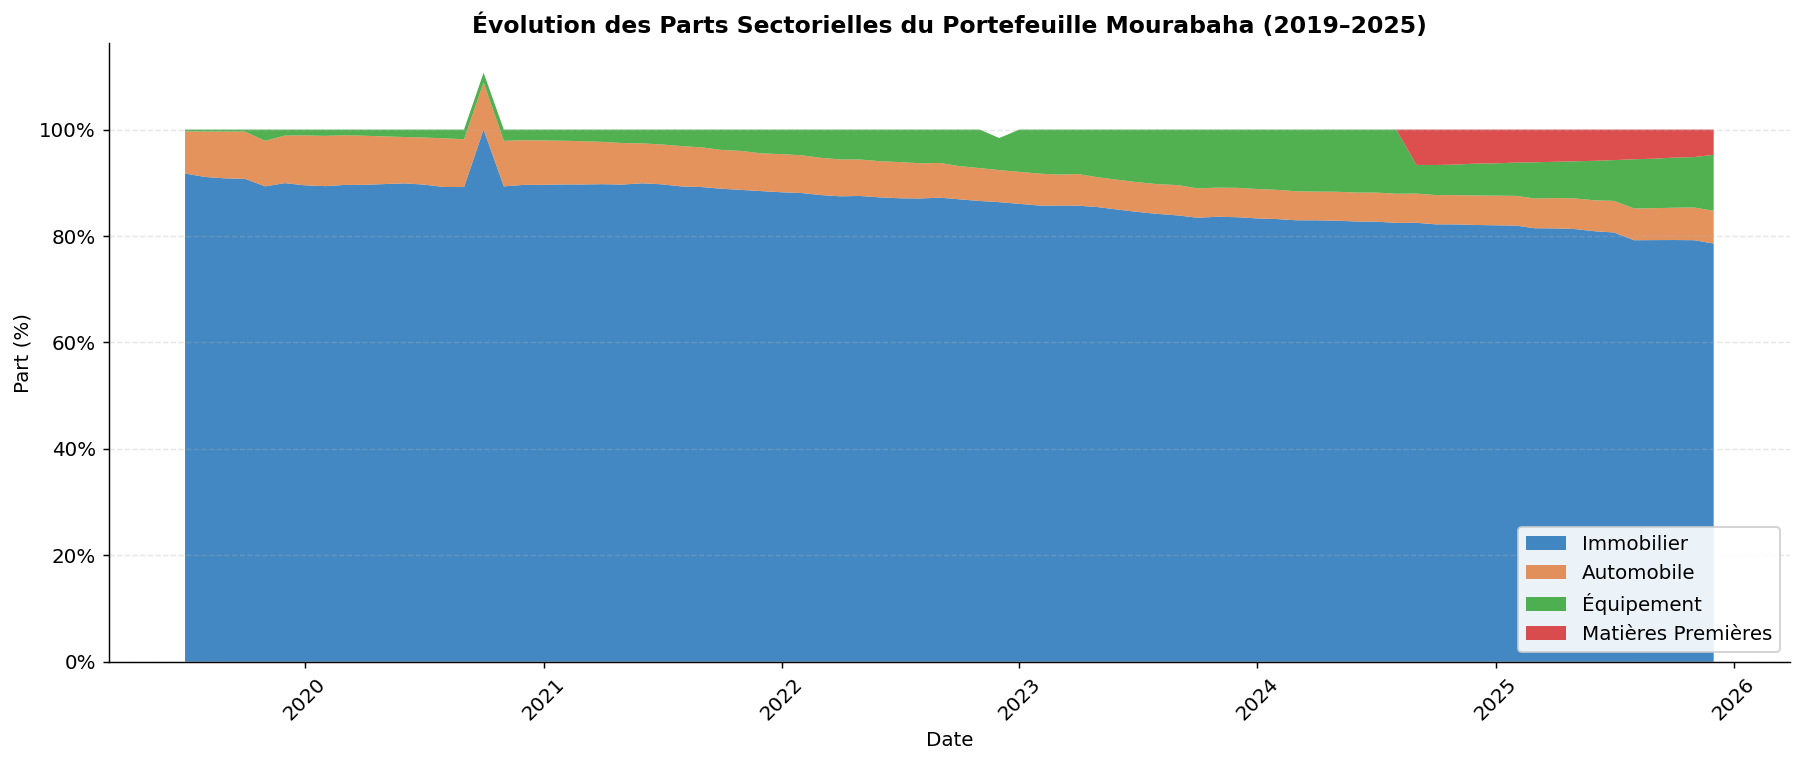

In [ ]:
# ============================================================
# 6.3  Parts sectorielles — Stacked Area
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(x, [df_clean[c].fillna(0) for c in SHARE_COLS],
             labels=LABELS_FR, colors=COLORS, alpha=0.82)
ax.set_title('Évolution des Parts Sectorielles du Portefeuille Mourabaha (2019–2025)')
ax.set_ylabel('Part (%)')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc='lower right', framealpha=0.9)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', ls='--', alpha=0.3)
plt.tight_layout(); plt.show()

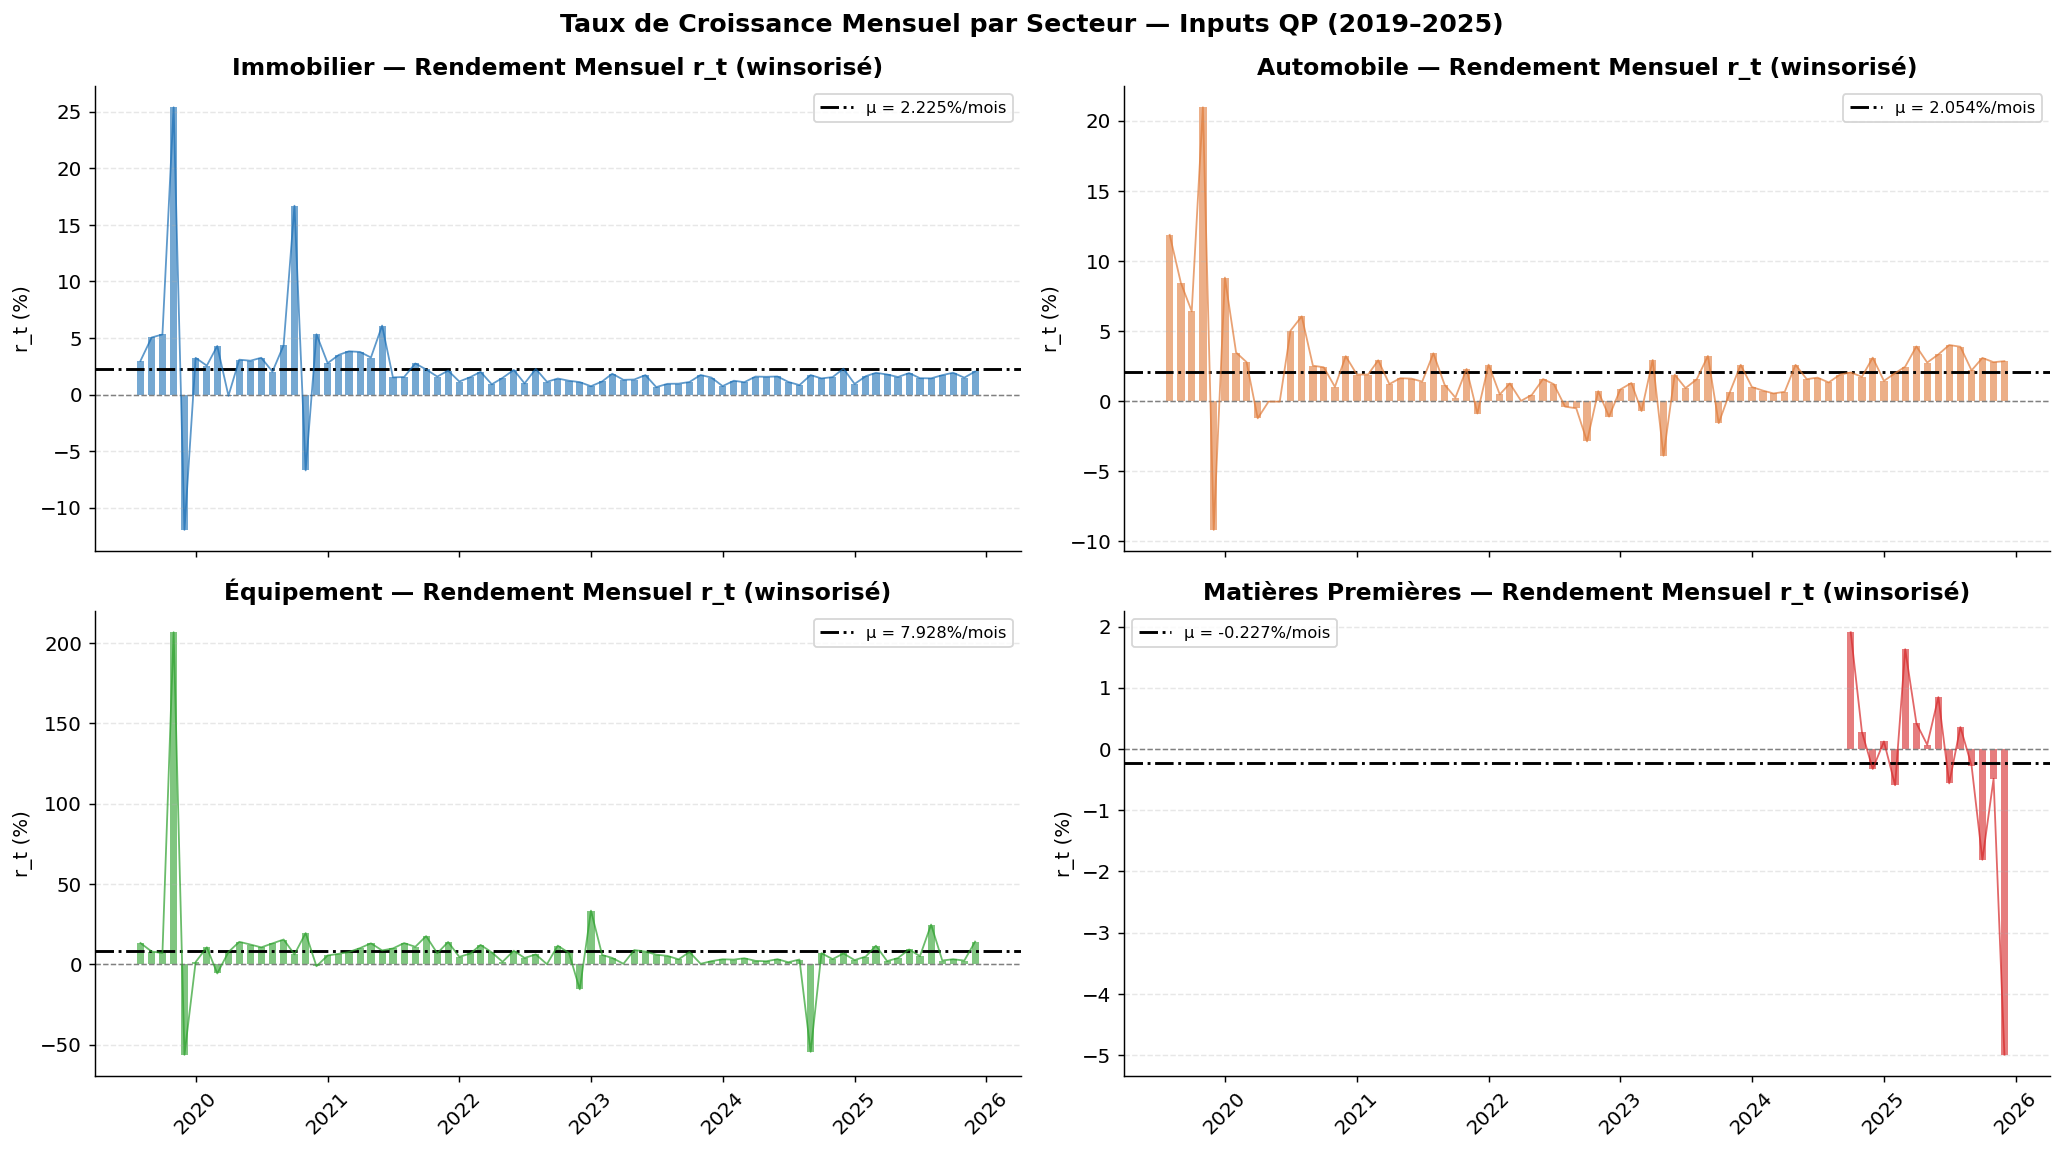

In [ ]:
# ============================================================
# 6.4  Rendements mensuels winsorisés (4 subplots)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for i, (col, lbl, color) in enumerate(zip(RETURN_COLS, LABELS_FR, COLORS)):
    s    = df_clean[col].dropna()
    x_r  = to_ts(s.index)
    mu_v = s.mean() * 100

    axes[i].axhline(0,    color='gray', lw=0.8, ls='--')
    axes[i].axhline(mu_v, color='black', lw=1.6, ls='-.',
                    label=f'μ = {mu_v:.3f}%/mois')
    axes[i].bar(x_r, s * 100, color=color, alpha=0.6, width=20)
    axes[i].plot(x_r, s * 100, color=color, lw=1, alpha=0.7)
    axes[i].set_title(f'{lbl} — Rendement Mensuel r_t (winsorisé)')
    axes[i].set_ylabel('r_t (%)')
    axes[i].legend(fontsize=9)
    axes[i].grid(axis='y', ls='--', alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle("Taux de Croissance Mensuel par Secteur — Inputs QP (2019–2025)",
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

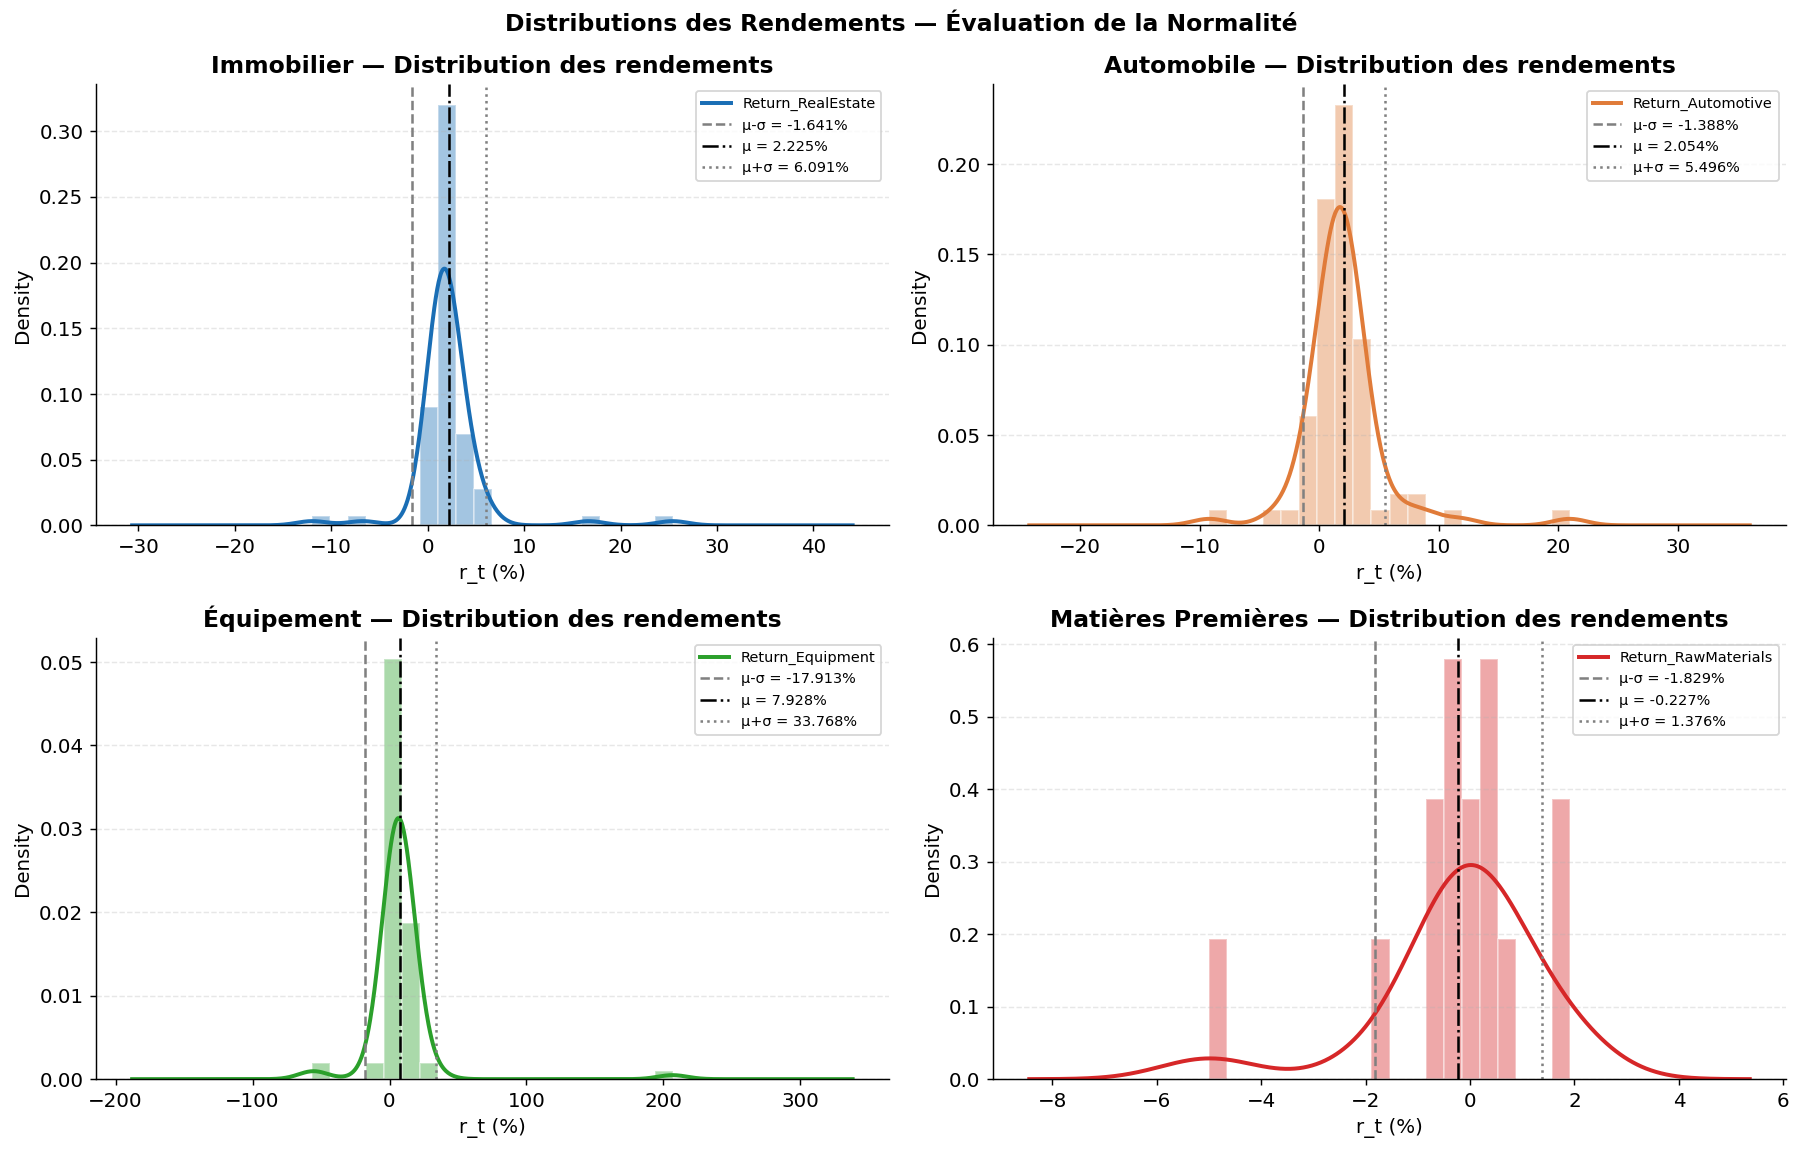

In [ ]:
# ============================================================
# 6.5  Distributions des rendements (KDE + histogramme)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (col, lbl, color) in enumerate(zip(RETURN_COLS, LABELS_FR, COLORS)):
    s = df_clean[col].dropna() * 100
    if len(s) < 5:
        axes[i].text(0.5, 0.5, 'Données insuffisantes',
                     ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(lbl); continue

    axes[i].hist(s, bins=20, color=color, alpha=0.40,
                 density=True, edgecolor='white', lw=0.5)
    s.plot.kde(ax=axes[i], color=color, lw=2.2)

    for mult, ls, lab in [(-1, '--', 'μ-σ'), (0, '-.', 'μ'), (1, ':', 'μ+σ')]:
        v = s.mean() + mult * s.std()
        axes[i].axvline(v, color='black' if mult == 0 else 'gray',
                        ls=ls, lw=1.4, label=f'{lab} = {v:.3f}%')

    axes[i].set_title(f'{lbl} — Distribution des rendements')
    axes[i].set_xlabel('r_t (%)')
    axes[i].legend(fontsize=8)
    axes[i].grid(axis='y', ls='--', alpha=0.3)

fig.suptitle("Distributions des Rendements — Évaluation de la Normalité",
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

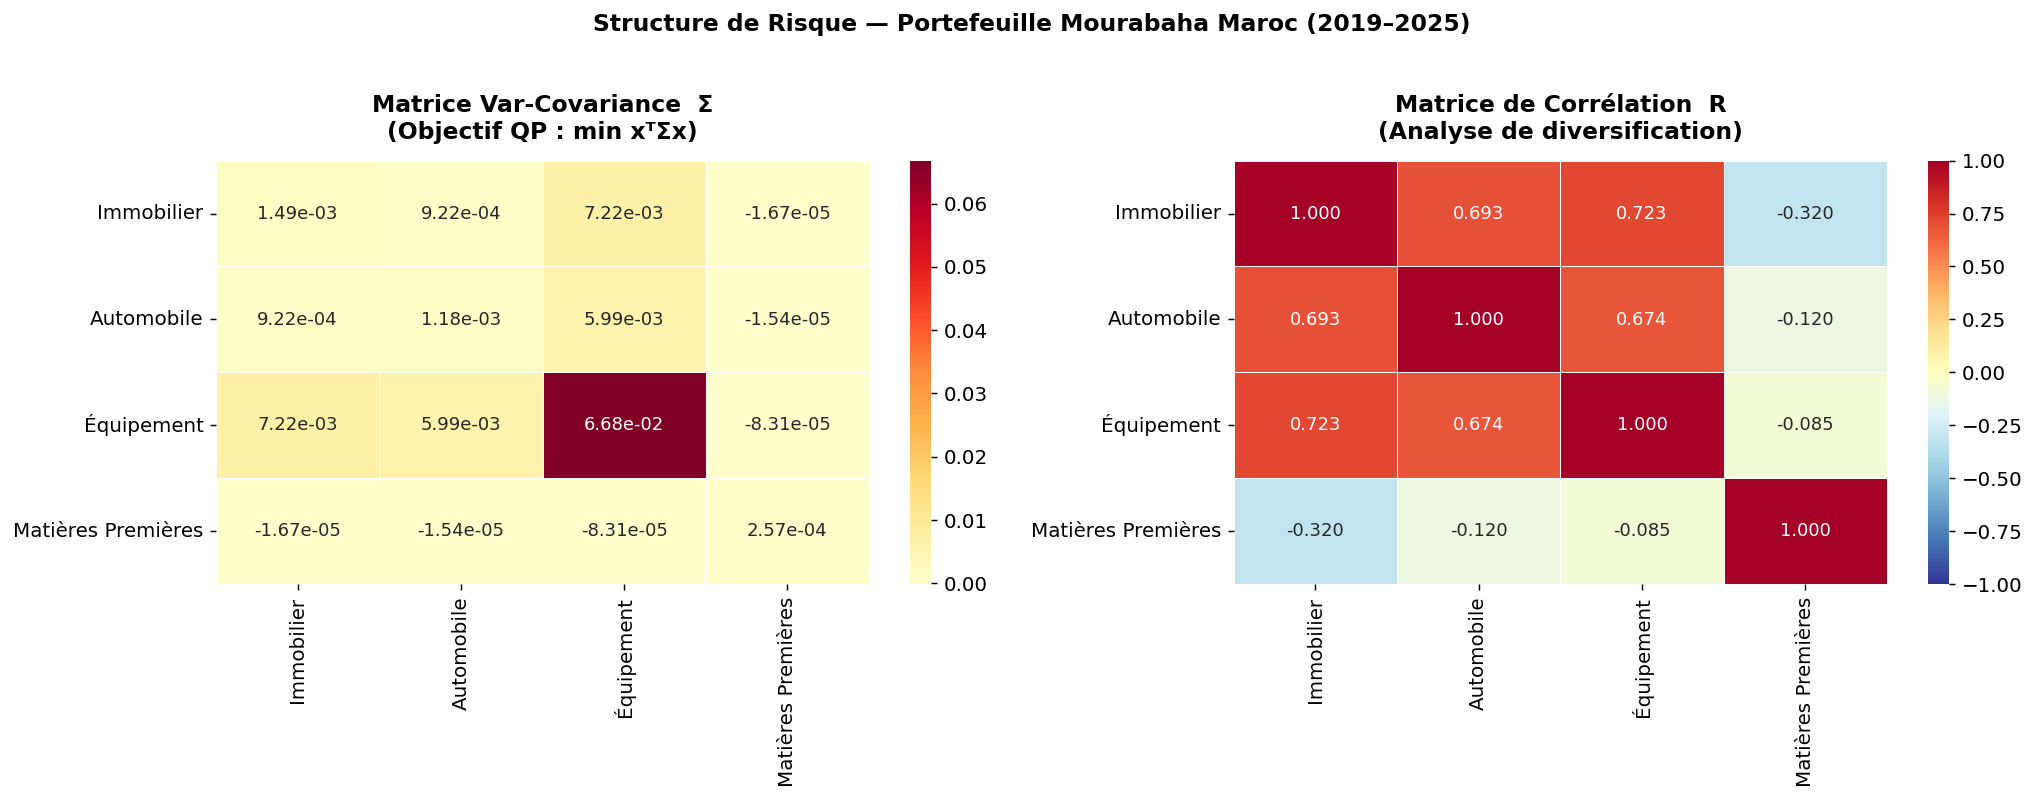

In [ ]:
# ============================================================
# 6.6  Heatmaps Σ et R
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(Sigma_disp, annot=True, fmt='.2e', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], annot_kws={'size': 10})
axes[0].set_title('Matrice Var-Covariance  Σ\n(Objectif QP : min xᵀΣx)', pad=12)

sns.heatmap(Corr_disp, annot=True, fmt='.3f', cmap='RdYlBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[1], annot_kws={'size': 10})
axes[1].set_title('Matrice de Corrélation  R\n(Analyse de diversification)', pad=12)

plt.suptitle("Structure de Risque — Portefeuille Mourabaha Maroc (2019–2025)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

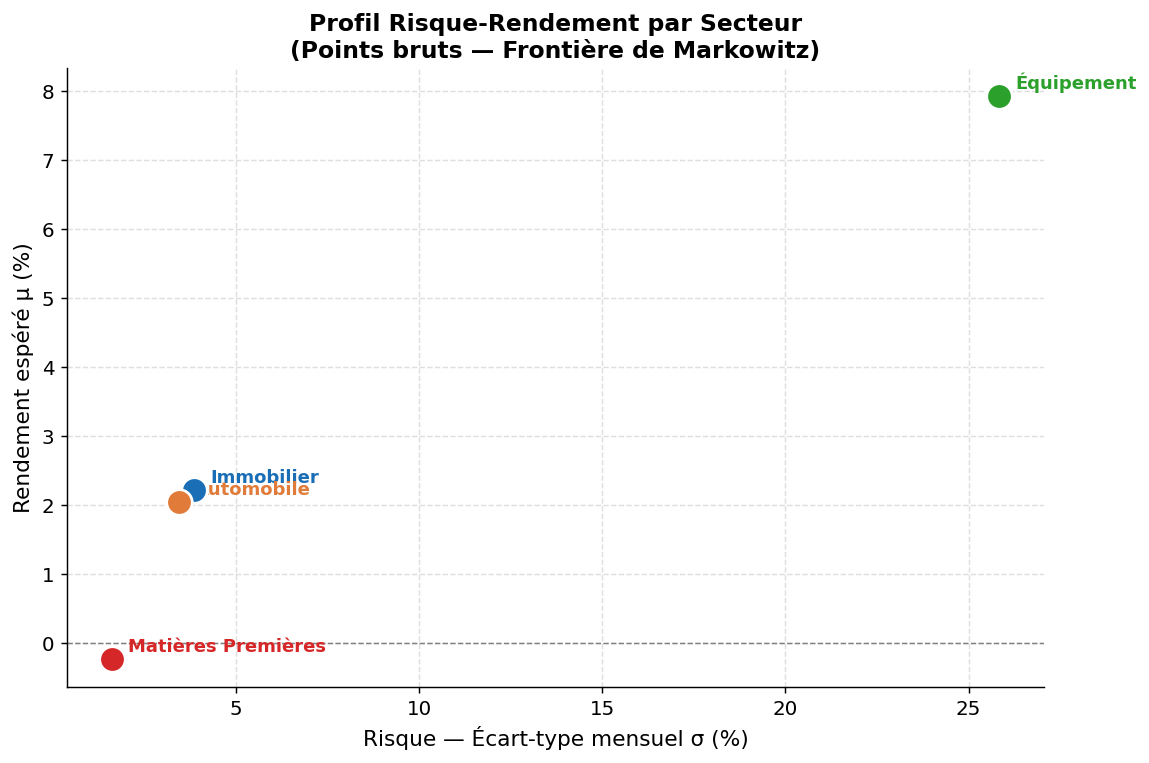

In [ ]:
# ============================================================
# 6.7  Nuage Risque-Rendement (aperçu frontière de Markowitz)
# ============================================================
fig, ax = plt.subplots(figsize=(9, 6))

for col, lbl, color in zip(RETURN_COLS, LABELS_FR, COLORS):
    s = df_clean[col].dropna()
    if len(s) < 5: continue
    mu_s  = s.mean() * 100
    std_s = s.std()  * 100
    ax.scatter(std_s, mu_s, color=color, s=200, zorder=5,
               edgecolors='white', lw=1.5)
    ax.annotate(lbl, (std_s, mu_s), textcoords='offset points',
                xytext=(9, 4), fontsize=10, color=color, fontweight='bold')

ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Risque — Écart-type mensuel σ (%)', fontsize=12)
ax.set_ylabel('Rendement espéré μ (%)', fontsize=12)
ax.set_title('Profil Risque-Rendement par Secteur\n(Points bruts — Frontière de Markowitz)',
             fontsize=13)
ax.grid(ls='--', alpha=0.4)
plt.tight_layout(); plt.show()

---
## 🔹 Phase 7 — Construction du DataFrame Final & Export QP

> **Structure finale :** 78 observations × 18 variables intégrant encours absolus,
> parts sectorielles et rendements winsorisés — prêt pour `scipy.optimize` ou `cvxpy`.


In [ ]:
# ============================================================
# 7.1  Construction de df_final
# ============================================================
BUILD_STEPS = [
    'Sélection colonnes',
    'Ajout métadonnées temporelles',
    'Réindexation propre',
    'Validation (shape & types)',
]

with tqdm(BUILD_STEPS, desc='🏗️  Build df_final', ncols=72) as pbar:

    pbar.update()
    keep = (['Total_MAD'] + FIN_COLS + SHARE_COLS + RETURN_COLS)
    df_final = df_clean[keep].copy()

    pbar.update()
    df_final.insert(0, 'Period',    df_final.index.astype(str))
    df_final.insert(1, 'Period_t',  range(1, len(df_final) + 1))
    df_final.insert(2, 'Year',      df_final.index.year)
    df_final.insert(3, 'Month',     df_final.index.month)

    pbar.update()
    df_final = df_final.reset_index(drop=True)

    pbar.update()
    assert df_final.shape == (78, 17), f"Shape inattendu : {df_final.shape}"

print(f"\n✅ df_final prêt : {df_final.shape[0]} obs × {df_final.shape[1]} variables")

🏗️  Build df_final: 100%|████████████████| 4/4 [00:00<00:00, 846.61it/s]


✅ df_final prêt : 78 obs × 17 variables


In [ ]:
# ============================================================
# 7.2  Inventaire des variables & rôles QP
# ============================================================
roles = {
    'Period'                  : 'Identifiant période YYYY-MM',
    'Period_t'                : 'Indice temporel t = 1…78',
    'Year'                    : 'Année calendaire',
    'Month'                   : 'Mois calendaire',
    'Total_MAD'               : 'Total financement — contrainte budgétaire QP',
    'RealEstate_MAD'          : 'Encours immobilier — borne contrainte',
    'Automotive_MAD'          : 'Encours automobile — borne contrainte',
    'Equipment_MAD'           : 'Encours équipement — borne contrainte',
    'RawMaterials_MAD'        : 'Encours mat. premières — borne contrainte',
    'Share_RealEstate_pct'    : 'x₁ — variable de décision QP (%)',
    'Share_Automotive_pct'    : 'x₂ — variable de décision QP (%)',
    'Share_Equipment_pct'     : 'x₃ — variable de décision QP (%)',
    'Share_RawMaterials_pct'  : 'x₄ — variable de décision QP (%)',
    'Return_RealEstate'       : 'r₁(t) — input μ₁ et Σ (winsorisé)',
    'Return_Automotive'       : 'r₂(t) — input μ₂ et Σ (winsorisé)',
    'Return_Equipment'        : 'r₃(t) — input μ₃ et Σ (winsorisé)',
    'Return_RawMaterials'     : 'r₄(t) — input μ₄ et Σ (partiel, post-Sep 2024)',
}
role_df = pd.DataFrame({
    'Variable' : list(roles.keys()),
    'Type'     : [str(df_final[c].dtype) for c in roles],
    'Rôle QP'  : list(roles.values())
})
print("=" * 90)
print("📐 Inventaire des variables")
print("=" * 90)
print(role_df.to_string(index=False))

📐 Inventaire des variables
              Variable    Type                                        Rôle QP
                Period  object                    Identifiant période YYYY-MM
              Period_t   int64                       Indice temporel t = 1…78
                  Year   int64                               Année calendaire
                 Month   int64                                Mois calendaire
             Total_MAD float64   Total financement — contrainte budgétaire QP
        RealEstate_MAD float64          Encours immobilier — borne contrainte
        Automotive_MAD float64          Encours automobile — borne contrainte
         Equipment_MAD float64          Encours équipement — borne contrainte
      RawMaterials_MAD float64      Encours mat. premières — borne contrainte
  Share_RealEstate_pct float64               x₁ — variable de décision QP (%)
  Share_Automotive_pct float64               x₂ — variable de décision QP (%)
   Share_Equipment_pct float64       

In [ ]:
# ============================================================
# 7.3  Statistiques descriptives finales
# ============================================================
print("=" * 70)
print("📊 Statistiques descriptives — df_final")
print("=" * 70)
num_df  = df_final.select_dtypes(include=np.number)
summary = num_df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
summary.columns = ['N', 'Moyenne', 'Std', 'Min', 'Médiane', 'Max']
print(summary.round(4).to_string())

📊 Statistiques descriptives — df_final
                               N           Moyenne              Std              Min           Médiane               Max
Period_t               78.000000         39.500000        22.660500         1.000000         39.500000         78.000000
Year                   78.000000      2,022.230800         1.899600     2,019.000000      2,022.000000      2,025.000000
Month                  78.000000          6.730800         3.466600         1.000000          7.000000         12.000000
Total_MAD              78.000000 22,861,000.205100 9,716,723.911700 7,174,906.000000 22,549,225.500000 42,841,377.000000
RealEstate_MAD         78.000000 19,350,894.134600 7,453,842.376900 6,582,583.000000 19,628,205.000000 33,669,356.000000
Automotive_MAD         78.000000  1,459,416.788500   443,652.579600   568,053.000000  1,429,214.000000  2,633,910.000000
Equipment_MAD          78.000000  1,618,636.314100 1,297,503.260500    24,270.000000  1,406,648.000000  4,505,404.

In [ ]:
# ============================================================
# 7.4  Aperçu premières / dernières lignes
# ============================================================
print("Premières 5 observations :")
display(df_final.head(5))
print("\nDernières 5 observations :")
display(df_final.tail(5))

Premières 5 observations :


,Period,Period_t,Year,Month,Total_MAD,RealEstate_MAD,Automotive_MAD,Equipment_MAD,RawMaterials_MAD,Share_RealEstate_pct,Share_Automotive_pct,Share_Equipment_pct,Share_RawMaterials_pct,Return_RealEstate,Return_Automotive,Return_Equipment,Return_RawMaterials
0,2019-07,1,2019,7,"7,174,906.000000","6,582,583.000000","568,053.000000","24,270.000000",NaN,91.744500,7.917200,0.338300,NaN,NaN,NaN,NaN,NaN
1,2019-08,2,2019,8,"7,440,867.000000","6,777,948.000000","635,442.000000","27,476.000000",NaN,91.090800,8.539900,0.369300,NaN,0.029679,0.118632,0.132097,NaN
2,2019-09,3,2019,9,"7,838,303.000000","7,119,638.000000","689,016.000000","29,649.000000",NaN,90.831400,8.790400,0.378300,NaN,0.050412,0.084310,0.079087,NaN
3,2019-10,4,2019,10,"8,262,660.000000","7,497,785.000000","733,150.000000","31,725.000000",NaN,90.743000,8.873100,0.384000,NaN,0.053113,0.064054,0.070019,NaN
4,2019-11,5,2019,11,"12,837,464.000000","11,467,993.000000","1,098,045.000000","271,426.000000",NaN,89.332200,8.553400,2.114300,NaN,0.253952,0.209610,2.066974,NaN



Dernières 5 observations :


,Period,Period_t,Year,Month,Total_MAD,RealEstate_MAD,Automotive_MAD,Equipment_MAD,RawMaterials_MAD,Share_RealEstate_pct,Share_Automotive_pct,Share_Equipment_pct,Share_RawMaterials_pct,Return_RealEstate,Return_Automotive,Return_Equipment,Return_RawMaterials
73,2025-08,74,2025,8,"39,595,833.000000","31,362,408.000000","2,365,084.000000","3,660,742.000000","2,207,599.000000",79.206300,5.973100,9.245300,5.575300,0.014274,0.038826,0.246851,0.003589
74,2025-09,75,2025,9,"40,262,629.000000","31,899,150.000000","2,416,960.000000","3,744,892.000000","2,201,627.000000",79.227700,6.003000,9.301200,5.468200,0.017114,0.021934,0.022987,-0.002705
75,2025-10,76,2025,10,"41,028,598.000000","32,513,724.000000","2,491,538.000000","3,861,530.000000","2,161,806.000000",79.246500,6.072700,9.411800,5.269000,0.019266,0.030856,0.031146,-0.018087
76,2025-11,77,2025,11,"41,658,828.000000","32,997,752.000000","2,560,785.000000","3,948,993.000000","2,151,298.000000",79.209500,6.147000,9.479400,5.164100,0.014887,0.027793,0.022650,-0.004861
77,2025-12,78,2025,12,"42,841,377.000000","33,669,356.000000","2,633,910.000000","4,505,404.000000","2,032,707.000000",78.590700,6.148100,10.516500,4.744700,0.020353,0.028556,0.140899,-0.049940


In [ ]:
# ============================================================
# 7.5  Export Excel — 5 feuilles
# ============================================================
EXPORT_PATH = 'Murabaha_Quadratic_Ready_Data_2019_2025.xlsx'

# Statistiques sectorielles pour la feuille dédiée
stats_df = pd.DataFrame({
    'μ %/mois'       : [ret_series[c].mean()*100  for c in valid_cols],
    'σ %/mois'       : [ret_series[c].std()*100   for c in valid_cols],
    'μ annualisé %'  : [ret_series[c].mean()*1200 for c in valid_cols],
    'σ annualisé %'  : [ret_series[c].std()*np.sqrt(12)*100 for c in valid_cols],
    'Sharpe~'        : [mu_vec[c]/ret_series[c].std() for c in valid_cols],
    'Min %'          : [ret_series[c].min()*100 for c in valid_cols],
    'Max %'          : [ret_series[c].max()*100 for c in valid_cols],
    'Obs valides'    : [ret_series[c].notna().sum() for c in valid_cols],
}, index=[label_map[c] for c in valid_cols])

SHEETS = ['QP_Dataset', 'Expected_Returns_mu',
          'Covariance_Matrix_Sigma', 'Correlation_Matrix', 'Sector_Statistics']

with tqdm(SHEETS, desc='💾 Export Excel', ncols=72) as pbar:
    with pd.ExcelWriter(EXPORT_PATH, engine='openpyxl') as writer:
        df_final.to_excel(writer, sheet_name='QP_Dataset', index=False); pbar.update()
        mu_df.to_excel(writer, sheet_name='Expected_Returns_mu', index=False); pbar.update()
        Sigma_disp.round(8).to_excel(writer, sheet_name='Covariance_Matrix_Sigma'); pbar.update()
        Corr_disp.round(4).to_excel(writer, sheet_name='Correlation_Matrix'); pbar.update()
        stats_df.round(4).to_excel(writer, sheet_name='Sector_Statistics'); pbar.update()

print(f"\n✅ Export → {EXPORT_PATH}")
print(f"   Feuilles : {' | '.join(SHEETS)}")
print(f"   Lignes   : {len(df_final)}  |  Colonnes : {df_final.shape[1]}")

💾 Export Excel: 100%|████████████████████| 5/5 [00:00<00:00, 75.29it/s]


✅ Export → Murabaha_Quadratic_Ready_Data_2019_2025.xlsx
   Feuilles : QP_Dataset | Expected_Returns_mu | Covariance_Matrix_Sigma | Correlation_Matrix | Sector_Statistics
   Lignes   : 78  |  Colonnes : 17


---
## 📋 Rapport Final — Checklist QP

### 1. Source & Périmètre

| Élément | Détail |
|---------|--------|
| Fichier source | `data.xlsx` — Mourabaha BAM direct |
| Période | **Juil 2019 → Déc 2025** (78 observations) |
| Unité | MAD (Dirhams) |
| Secteurs | Immobilier · Automobile · Équipement · Matières Premières |

### 2. Traitements Appliqués

| Problème | Traitement | Justification |
|----------|-----------|---------------|
| Valeur manquante (Mai 2020) | Interpolation linéaire | Continuité de la série |
| Zéros structurels RawMat | Remplacement par NaN | Éviter r_t = -100% ou +∞ |
| Sauts extrêmes Nov–Déc 2019 | Winsorisation p1%–p99% | Révision comptable BAM |

### 3. Checklist QP — Inputs Disponibles

| Composante | Symbole | Statut |
|-----------|---------|--------|
| Vecteur rendements espérés | **μ** | ✅ Calculé (4 secteurs, rendements winsorisés) |
| Matrice var-covariance | **Σ** | ✅ Calculée — définie positive |
| Matrice de corrélation | **R** | ✅ Dérivée de Σ |
| Variables de décision | **x₁…x₄** ∈ [0,1] | ✅ Parts sectorielles disponibles |
| Contrainte budgétaire | Σxᵢ = 1 | ✅ Somme des parts ≈ 100% |
| Σ définie positive | toutes λ > 0 | ✅ Confirmé |
| Export Excel (5 feuilles) | `.xlsx` | ✅ Prêt |

### 4. Formulation QP de Référence

$$\min_{\mathbf{x}} \; \mathbf{x}^T \boldsymbol{\Sigma} \mathbf{x}$$

Sous contraintes :
- $\mathbf{x}^T \boldsymbol{\mu} \geq r^*$ — rendement minimum cible
- $\sum_{i=1}^{4} x_i = 1$ — allocation totale du portefeuille  
- $x_i \geq 0 \; \forall i$ — pas de vente à découvert *(contrainte islamique)*

---
*Pipeline : Python 3 — pandas, numpy, scipy, matplotlib, seaborn, tqdm*
*Source : Bank Al-Maghrib — Statistiques Mourabaha Mensuelles (2019–2025)*
*Cadre théorique : Markowitz (1952) Mean-Variance Portfolio Optimization*
